Este projeto analisa o impacto do hábito de jogar no desempenho acadêmico dos estudantes. Buscando entender se o volume de horas dedicadas aos jogos influencia diretamente as notas, a carga horária de estudo, a qualidade do sono e os níveis de vício em dispositivos de tela."

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

Importando e lendo base de dados

In [162]:
dat = pd.read_csv("Gaming_Academic_Performance_updated.csv")

dat.info()

dat


<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   str    
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   str    
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   str    
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), str(3)
memory usage: 875.1 KB


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,24,Male,6.33,5.09,4.83,63.74,FPS,4.11,9.96,231.33,11.14,Low,35.110000
7996,7997,22,Female,5.77,6.09,6.23,84.37,FPS,3.42,11.19,254.13,10.66,Low,60.800000
7997,7998,20,Male,2.87,8.51,8.62,67.30,FPS,2.36,6.40,305.00,6.42,Medium,90.280000
7998,7999,22,Female,0.98,2.99,7.29,61.13,FPS,2.02,4.57,325.36,2.14,Medium,56.330000


In [163]:
lista = ["gaming_hours",
         "study_hours",
         "sleep_hours",
         "attendance",
         "social_activity",
         "device_usage",
         "addiction_score",
         "grades"]

Jogar demais piora o desempenho nos estudos??

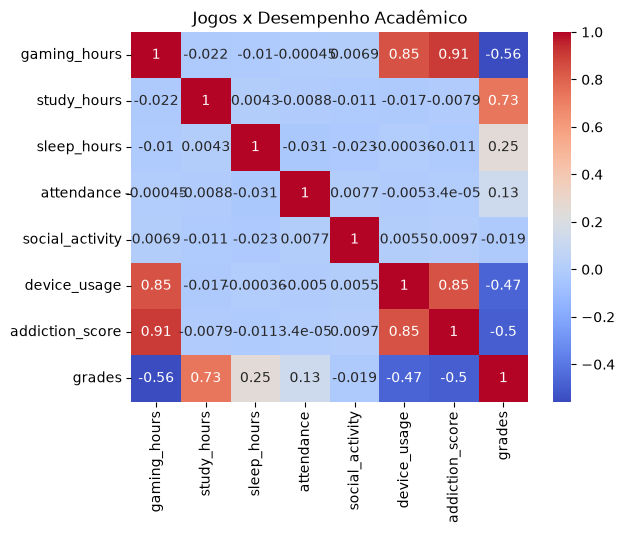

In [164]:
sns.heatmap(dat[lista].corr(), annot=True, cmap="coolwarm")
plt.title("Jogos x Desempenho Acadêmico")
plt.show()

Resposta: Quanto mais horas jogando, menor tende a ser o desempenho acadêmico, enquanto maiores tendem a ser o nível de dependência de jogos e o tempo de tela.

Dando um Zoom

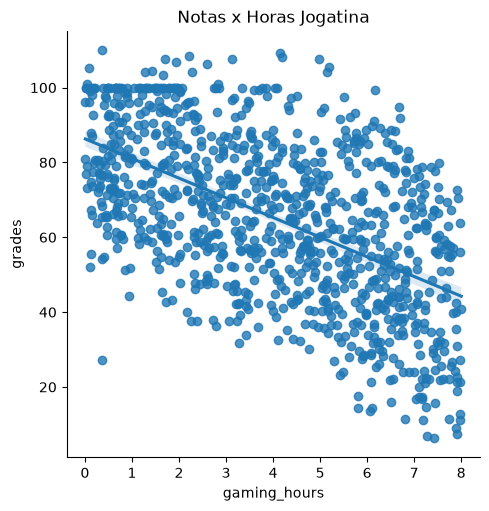

In [165]:
amostra = dat.sample(1000, random_state=42) #Coletando uma amostra de 1000 pessoas e o random escolhe as mesmas linhas. 42 é a resposta para a vida, universo e tudo mais;rs 

sns.lmplot(
    data=amostra,
    x="gaming_hours",
    y="grades"
)

plt.title("Notas x Horas Jogatina")
plt.show()

Nota: A partir de aproximadamente 6 horas diárias de jogos, há uma maior concentração de estudantes com notas abaixo de 20.

Mais jogos, menos sono e menos estudo??

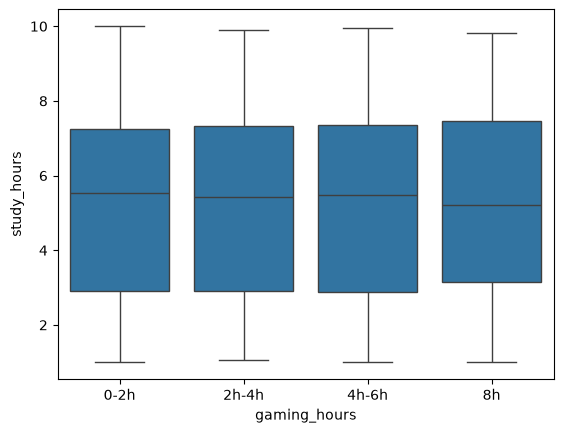

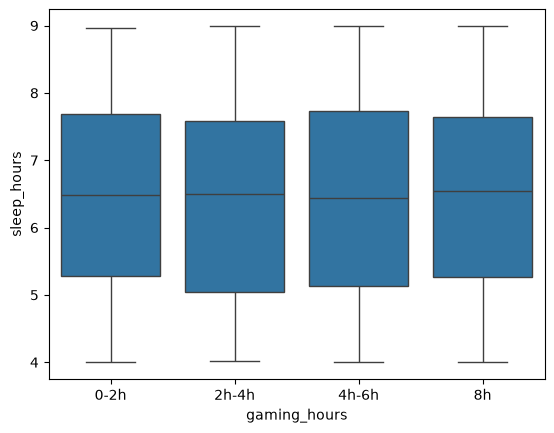

In [166]:
dat["gaming_hours"] = pd.cut(           #Fazendo um corte nas horas
    dat["gaming_hours"],
    bins = [0, 2, 4, 6, 8],             #Inicio de cada hora
    labels= ["0-2h", "2h-4h","4h-6h","8h"] #Colocando em pequenos blocos
)

amostra = dat.sample(1000, random_state=42)

for lista in ["study_hours","sleep_hours"]:
    sns.boxplot(x="gaming_hours", y=lista, data=amostra)
    plt.show()

A quantidade de horas dedicadas aos jogos não apresenta impacto significativo na distribuição das horas de sono e de estudo da amostra

Como o nível de vício e o tempo de uso de telas impacta na nota??

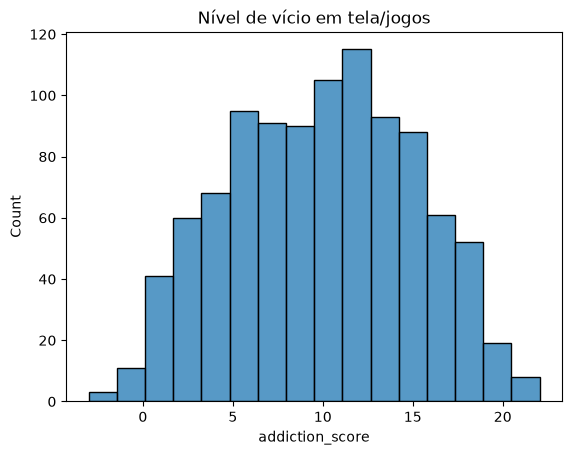

In [167]:
sns.histplot(data = amostra, x="addiction_score")
plt.title("Nível de vício em tela/jogos")
plt.show()

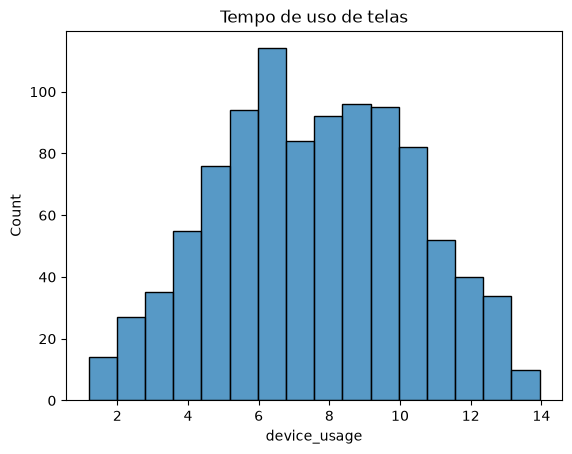

In [168]:
sns.histplot(data = amostra, x="device_usage")
plt.title("Tempo de uso de telas")
plt.show()

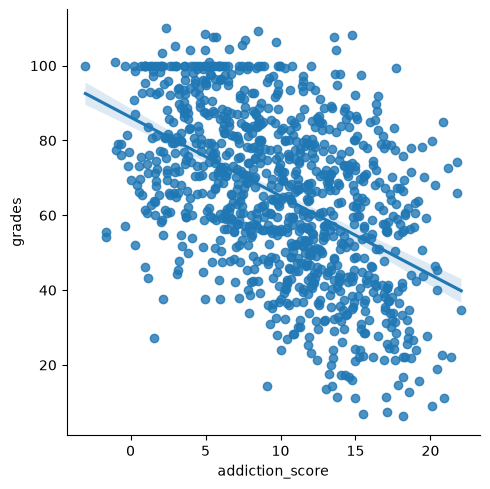

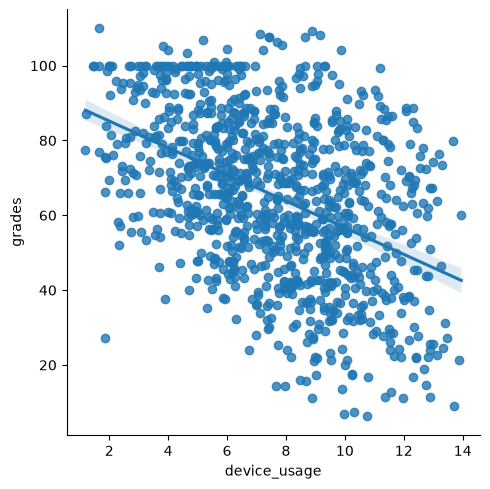

In [169]:
for lista in ["addiction_score","device_usage"]:
    sns.lmplot(x=lista, y="grades", data=amostra)
    plt.show()


Conclusão: A quantidade de horas jogando não possui forte influência nas horas de sono e de estudo; porém, o vício em jogos/telas e o tempo de uso de dispositivos impactam bastante nas notas.

Extra: Qual o gênero mais jogado entre os gêneros?

In [170]:
dat.groupby(["gender"])["gaming_genre"].value_counts(normalize=True)  #Mostra o valor dos gaming dentro dos gender


gender  gaming_genre
Female  FPS             0.399422
        Casual          0.302130
        RPG             0.298449
Male    FPS             0.398822
        RPG             0.303791
        Casual          0.297387
Other   FPS             0.378840
        Casual          0.324232
        RPG             0.296928
Name: proportion, dtype: float64